In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../HICode")
from label_generation import generate_labels, save_generation_output
from label_clustering import cluster_labels_gpt, make_clustering_prompt
from map_clustering import *

# Main Page

## Step 1: Data Input
**Input Format: Tabular data  ===> Output Format: Tabular data**

### Upload Data / Connect to database
Requirement: For the user input, we require the dataset to be in a csv format with at least two columns: `text_id` and `text`. The `text_id` column should contain unique identifiers for each review, while the `text` column should contain the actual review text. The dataset can also include additional columns as metadata.



In [3]:
review_df = pd.read_csv("./doctor_review_sample1000.csv")
review_df.head()

,text_id,text,PhyID,platform
0,3103437,My mother in law was diagnosed with colon canc...,100711211,Vitals
1,3606054,I am very satisfied.,100823913,Vitals
2,3483408,I needed an ENT and since i dont require a pri...,100797376,Vitals
3,2349846,I came into Winthrop Emergency Room after a fa...,100538536,Vitals
4,2991163,The staff at PSW work cohesively to provide a ...,100685460,Yelp


Explanation: As shown above, I made a random sample of 1000 reviews from the doctor review corpus and saved it as a csv file, and will use it as a running example for illustration. The data was filtered with `review_df = review_df.sample(1000, random_state=42)` on a parquet file.

It has the required two columns: `text_id` and `text`, where `text_id` is a unique identifier for each review, and `text` contains the actual review text. 

The dataset can also include additional columns as metadata, such as doctor specialty, location, etc., which can be useful for further analysis. In this example, we include `PhyID` which is the unique identifier for each doctor, and `platform` which indicates the platform where the review was posted (e.g., Healthgrades, RateMDs, etc.).

### Specify Analysis Goal and Background

Current staus:
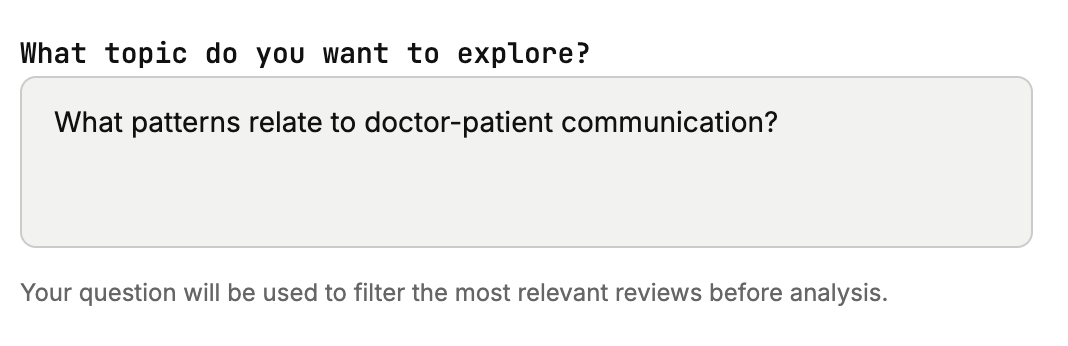


Here we implemented the function for user to write down the analysis goal.

Optional To-be-implemented: 

Add another user input part to specify the background of the analysis. For example, it can be a description of the dataset or a clearer definition on what to analyze if the analysis goal involves a concept that requires further clarification or domain knowledge. If user does not provide the background, we can use a default background description.

These two user inputs will be used to construct the system prompt for HiCode.

In [4]:
# What analysis do you want to explore?
coding_goal = "How did the patients get referred to the current provider?"

background = """
The online physician review dataset contains millions of public patient reviews 
about physicians from different healthcare providers. Public health researchers are 
interested in understanding exploratory research questions about patient experiences 
from these reviews.
"""



## Step 2: Run Analysis
**Input Format: Tabular data  ===> Output Format: JSON**

### Step 2.1 Data selection (TBD)
We should incorporate our milestone 1 project of data selection here, but less of a priority for now. For the time being, we can just run the analysis on the whole dataset, and then add the data selection component in the next iteration.

### Step 2.2: Label Generation
**Input Format: Tabular data ==> Output Format: JSON**

To prepare for running HiCode, we need to convert the input data into a key-value pairs dictionary format, where the keys are the `text_id` and the values are the corresponding `text`.

In [5]:
review_df["segment_id"] = review_df["text_id"].apply(lambda x: str(x)+"_0")
hicode_input = dict(zip(review_df["segment_id"], review_df["text"]))
hicode_input.keys()

dict_keys(['3103437_0', '3606054_0', '3483408_0', '2349846_0', '2991163_0', '2783355_0', '1570028_0', '2138802_0', '4564855_0', '3168966_0', '1396815_0', '4930959_0', '1825008_0', '4677636_0', '2056045_0', '2501833_0', '3873814_0', '1998834_0', '371307_0', '3874385_0', '235083_0', '3552757_0', '2908812_0', '3234016_0', '926521_0', '3887307_0', '2965041_0', '3730238_0', '1978407_0', '2031424_0', '3630352_0', '4556283_0', '2063824_0', '965071_0', '2026858_0', '4066860_0', '4654022_0', '1331997_0', '3744912_0', '4545884_0', '3693257_0', '3807236_0', '303555_0', '3461218_0', '4563712_0', '4107380_0', '2126391_0', '4061544_0', '4048625_0', '578318_0', '1353310_0', '4337475_0', '4189884_0', '4071924_0', '1560937_0', '144683_0', '1054528_0', '2438657_0', '4950668_0', '2672268_0', '4054924_0', '1350163_0', '24560_0', '1423290_0', '728924_0', '2949652_0', '1331519_0', '1059520_0', '3969323_0', '3642805_0', '4837279_0', '1674233_0', '2246953_0', '193931_0', '1475278_0', '2733857_0', '27278_0', '

In [6]:
# Define the system prompt for label generation

system_prompt = f"""
{background}

We are using the queries to this bot to conduct INDUCTIVE Coding. The labeling aims to {coding_goal}

Instruction:
- Label the input only when it is HIGHLY RELEVANT and USEFUL for {coding_goal}.
- Then, define the phrase of the label. The label description should be observational, concise and clear.
- ONLY output the label and DO NOT output any explanation.

Format:
- Define the label using the format \"LABEL: [The phrase of the label]\". 
- If there are multiple labels, each label is a new line. 
- If the input is irrelevant, use \"LABEL: [Irrelevant]\". 
"""

# Configuration 
config = {
# Generation Model 
"model_name": "gpt-4o-mini",

# Generation
"generation_output_dir": "./results/generation", # Change Me to your desired output directory

# CLustering Model
"cluster_model_name": "gpt-4o-mini",
"cluster_output_dir": "./results/clustering" # Change Me to your desired output directory
}

In [30]:
gen_result = generate_labels(hicode_input, 
                             system_prompt, 
                             config)
gen_result_id = save_generation_output(gen_result, 
                                       config["generation_output_dir"])

100%|██████████| 1000/1000 [12:28<00:00,  1.34it/s] 

Saving generation output to ./results/generation/generation_82ca572c-44ca-11f1-981f-b2784844b6f9.json


### Step 2.3: Label Clustering
**Input Format: Tabular data ==> Output Format: JSON**

In [33]:
cluster_prompt = make_clustering_prompt(goal=coding_goal)
cluster_result = cluster_labels_gpt(gen_result, cluster_prompt, config, gen_result_id=gen_result_id)

========Run gpt-4o-mini Clustering=========
Number of batches: 2


100%|██████████| 2/2 [00:30<00:00, 15.37s/it]


Saved iteration 0 clustering result to ./results/clustering/clustering_82ca572c-44ca-11f1-981f-b2784844b6f9/cluster_iter_0.json
Number of batches: 1


100%|██████████| 1/1 [00:03<00:00,  3.58s/it]

Saved iteration 1 clustering result to ./results/clustering/clustering_82ca572c-44ca-11f1-981f-b2784844b6f9/cluster_iter_1.json


# Step 3: Visualization
# To be implemented: Visualization Page
**Input Format: JSON ==> Output Format: ?**

## Prevalence charts

### How many labels belong to each theme/category?

The following code maps the initial labels from generation staget to their corresponding clusters (i.e. themes), for a simple example, you could imagine

```
generated_label_map = {
    "dog": "animal",
    "cat": "animal",
    "carrot": "vegetable",
    "broccoli": "vegetable",
    "apple": "fruit",
    "banana": "fruit",
    "pear": "fruit",
} 
```

In [18]:
cluster_result_dir = "./results/clustering/clustering_82ca572c-44ca-11f1-981f-b2784844b6f9"
generated_label_map = create_mapping(cluster_result_dir)

Number of labels: 86
Iteration 1: 86 labels left


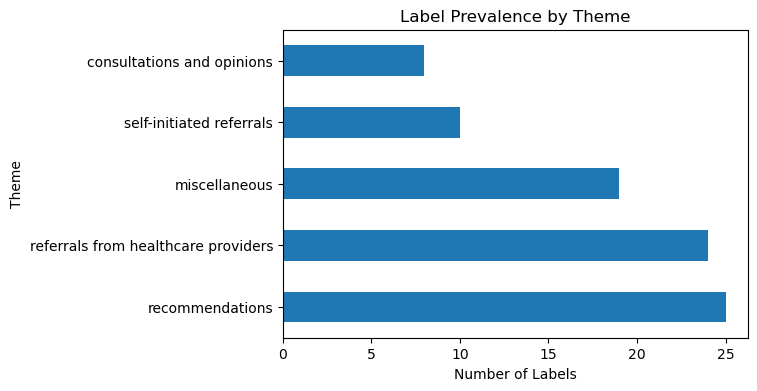

In [21]:

# Convert dict to DataFrame
df = pd.DataFrame(list(generated_label_map.items()), columns=["label", "theme"])

# Count occurrences per theme
counts = df["theme"].value_counts()

# Plot
counts.plot(kind="barh", figsize=(6, 4))

plt.ylabel("Theme")
plt.xlabel("Number of Labels")
plt.title("Label Prevalence by Theme")

plt.show()

### How many documents belong to each theme/category?

In [49]:
generation_result_file = "./results/generation/generation_82ca572c-44ca-11f1-981f-b2784844b6f9.json"
doc_labeled_by_theme = map_clusters(generation_result_file, generated_label_map)

In [50]:
# Convert to DataFrame for visualization
rows = []

for doc_id, doc_data in doc_labeled_by_theme.items():
    doc_labels = set()

    for ann in doc_data["LLM_Annotation"]:
        doc_labels.update(ann["label"])

    for label in doc_labels:
        rows.append({"doc_id": doc_id, "theme": label})

doc_prevalence_df = pd.DataFrame(rows)
doc_prevalence_df.head()


,doc_id,theme
0,3103437,referrals from healthcare providers
1,3483408,self-initiated referrals
2,2908812,referrals from healthcare providers
3,4061544,recommendations
4,4061544,self-initiated referrals


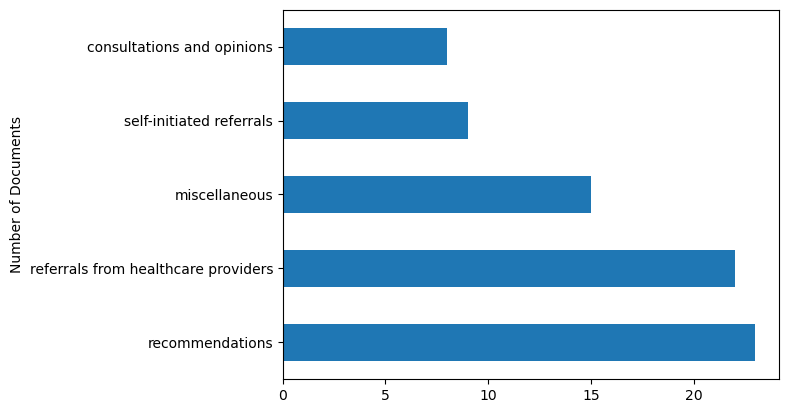

In [51]:
counts = doc_prevalence_df["theme"].value_counts()
counts.plot(kind="barh")

plt.ylabel("Number of Documents")
plt.show()

## Theme co-occurrence heatmap

In [54]:
from collections import defaultdict

# Get all themes
all_themes = set()

for doc in doc_labeled_by_theme.values():
    for ann in doc["LLM_Annotation"]:
        all_themes.update(ann["label"])

all_themes = sorted(all_themes)

# Initialize matrix
co_matrix = pd.DataFrame(
    0,
    index=all_themes,
    columns=all_themes
)

# Count co-occurrences
for doc in doc_labeled_by_theme.values():

    doc_labels = set()

    for ann in doc["LLM_Annotation"]:
        doc_labels.update(ann["label"])

    for l1 in doc_labels:
        for l2 in doc_labels:
            if l1 != l2:            
                co_matrix.loc[l1, l2] += 1


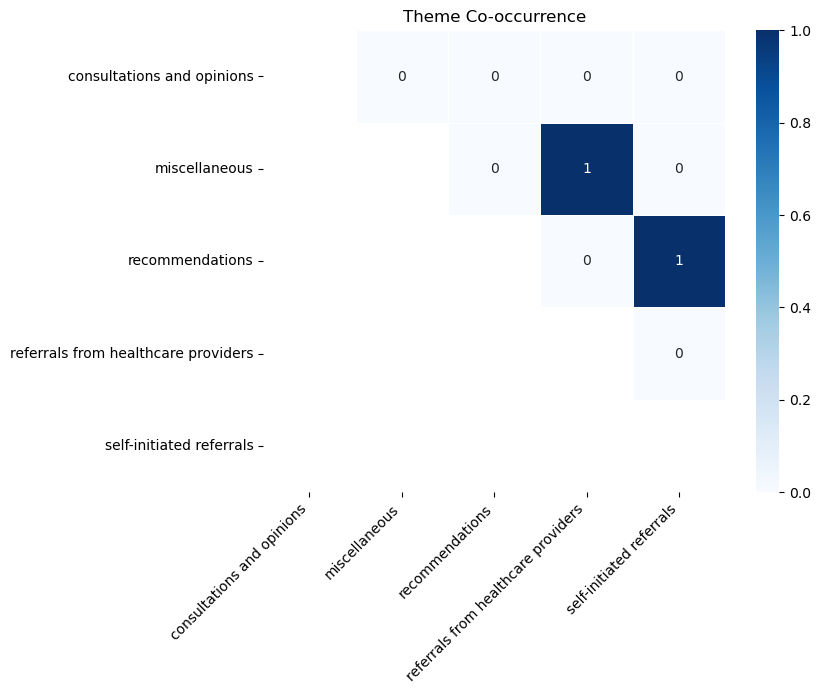

In [55]:
import numpy as np
# Plot
plt.figure(figsize=(8, 6))
mask = np.tril(np.ones_like(co_matrix, dtype=bool))

sns.heatmap(
    co_matrix,
    mask=mask,
    annot=True,
    cmap="Blues",
    square=True,
    linewidths=0.5
)

plt.title("Theme Co-occurrence")
plt.xticks(rotation=45, ha="right")
plt.show()